In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import multilabel_confusion_matrix



In [2]:
data = pd.read_csv("iris.csv")

print("First five rows of dataset:")
display(data.head())


First five rows of dataset:


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [3]:

print("Dataset Information:")
data.info()


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [4]:
print("Statistical Summary:")
display(data.describe())


Statistical Summary:


,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Shape of Dataset:")
print(data.shape)


Shape of Dataset:
(150, 5)


In [6]:
print("Missing Values:")
display(data.isnull().sum())


Missing Values:


sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

In [7]:
print("Unique Species:")
print(data["variety"].unique())


Unique Species:
<StringArray>
['Setosa', 'Versicolor', 'Virginica']
Length: 3, dtype: str


In [8]:
x = data[["sepal.length", "sepal.width", "petal.length", "petal.width"]]

y = data["variety"]

print("Independent Variables:")
display(x.head())

print("Dependent Variable:")
display(y.head())




Independent Variables:


,sepal.length,sepal.width,petal.length,petal.width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


Dependent Variable:


0    Setosa
1    Setosa
2    Setosa
3    Setosa
4    Setosa
Name: variety, dtype: str

In [9]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Encoded Target Values:")
print(y[:10])

print("Class Names:")
print(encoder.classes_)




Encoded Target Values:
[0 0 0 0 0 0 0 0 0 0]
Class Names:
['Setosa' 'Versicolor' 'Virginica']


In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=0
)

print("Training data shape:")
print(x_train.shape)

print("Testing data shape:")
print(x_test.shape)



Training data shape:
(105, 4)
Testing data shape:
(45, 4)


In [11]:
model = GaussianNB()

model.fit(x_train, y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [12]:
y_pred = model.predict(x_test)

print("Actual Output:")
print(y_test[:10])

print("Predicted Output:")
print(y_pred[:10])



Actual Output:
[2 1 0 2 0 2 0 1 1 1]
Predicted Output:
[2 1 0 2 0 2 0 1 1 1]


Confusion Matrix:
[[16  0  0]
 [ 0 18  0]
 [ 0  0 11]]


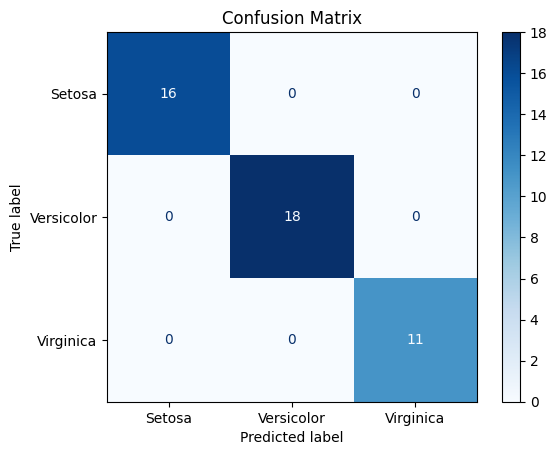

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=encoder.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [14]:
mcm = multilabel_confusion_matrix(y_test, y_pred)

for i, class_name in enumerate(encoder.classes_):
    tn, fp, fn, tp = mcm[i].ravel()
    
    print("Class:", class_name)
    print("True Positive  (TP):", tp)
    print("False Positive (FP):", fp)
    print("True Negative  (TN):", tn)
    print("False Negative (FN):", fn)
    print("--------------------------------")



Class: Setosa
True Positive  (TP): 16
False Positive (FP): 0
True Negative  (TN): 29
False Negative (FN): 0
--------------------------------
Class: Versicolor
True Positive  (TP): 18
False Positive (FP): 0
True Negative  (TN): 27
False Negative (FN): 0
--------------------------------
Class: Virginica
True Positive  (TP): 11
False Positive (FP): 0
True Negative  (TN): 34
False Negative (FN): 0
--------------------------------


In [15]:
accuracy = accuracy_score(y_test, y_pred)

error_rate = 1 - accuracy

precision = precision_score(y_test, y_pred, average="macro")

recall = recall_score(y_test, y_pred, average="macro")

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)




Accuracy: 1.0
Error Rate: 0.0
Precision: 1.0
Recall: 1.0


In [16]:

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        16
  Versicolor       1.00      1.00      1.00        18
   Virginica       1.00      1.00      1.00        11

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

